# Forces on the atoms, and relaxing a structure

The force on an atom is minus the derivative of the total energy with respect to
its position, taken at **frozen** wavefunctions, occupations and eigenvalues:

$$\mathbf F_I = -\left.\frac{\partial E_{\rm tot}
   [\{\psi\}, \{f\}, \boldsymbol\tau]}
   {\partial \boldsymbol\tau_I}\right|_{\psi,\, f,\, \varepsilon\ \rm fixed}$$

Freezing the states costs nothing, because the energy is stationary in them at
the converged solution: that is the Hellmann-Feynman theorem. What survives
beyond the bare electrostatic pull is the Pulay contribution from a basis that
moves with the atoms, and, for an ultrasoft dataset, the augmentation charge's
own displacement. Both fall out of the same derivative rather than being
written down separately, which is worth one sentence because it is a claim
about what the code can do: the derivative is taken of the energy itself.

On a two-atom silicon cell with the atoms pushed off their sites:

| | pypresso | `pw.x` |
|---|---|---|
| force on atom 0, along the bond | **0.06039736 Ry/bohr** | 0.06039673 |
| the same, five reference cases | | agree to **2e-5 Ry/bohr** |
| relaxed geometry | | agrees to **1e-6 bohr** |

A crystal with its atoms on their symmetry sites has no force at all, so a cell
with something to compute is one that has been displaced.

In [1]:
from pathlib import Path

import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si2-nc-force.in", pseudo_dir=PSEUDO)
forces = silicon.get_forces()
qe = read_qe_output(CASES / "reference.out.si2-nc-force")

print(comparison_table(
    [(f"atom {a}, {'xyz'[d]}", float(forces.forces[a, d]), float(qe.forces[a, d]))
     for a in range(2) for d in range(3)],
    fmt="{:.8f}", headers=("force [Ry/bohr]", "pypresso", "pw.x", "difference")))

[pypresso] the forces: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


force [Ry/bohr]     pypresso         pw.x  difference
atom 0, x         0.06039736   0.06039673     6.3e-07
atom 0, y        -0.00000000   0.00000000     3.2e-19
atom 0, z         0.00000000   0.00000000     3.2e-19
atom 1, x        -0.06039736  -0.06039673     6.3e-07
atom 1, y         0.00000000   0.00000000     3.2e-19
atom 1, z        -0.00000000   0.00000000     3.2e-19


`get_forces()` announced that it ran a self-consistent field calculation
first. There was no ground state cached, and a force is a derivative *at* one,
so it converged the density before differentiating it. Every `get_*` here
behaves that way, and says so rather than doing it quietly.

The two forces are equal and opposite, which is Newton's third law and is not
imposed anywhere: it is the sum rule that the total force on an isolated crystal
vanishes, and here it holds to 1e-17. The components across the bond are zero by
symmetry, and they are zero to the same accuracy rather than to the accuracy of
the force itself.

The comparison that trusts neither code is a **central difference of the total
energy** over re-converged displaced cells, which is what a force is by
definition. Measured offline on this cell with symmetry switched off, at a step
of 2e-3 bohr: the difference gives 0.06076082 Ry/bohr where the derivative gives
0.06076358, and the gap of 2.8e-6 is the finite difference's own truncation
error rather than a disagreement. It is quoted rather than run here because it
costs six self-consistent runs; it is `test_the_force_is_the_derivative_of_the_energy`
in the test suite, where it belongs.

## Relaxing the structure

`calculation = 'relax'` walks downhill with BFGS, a trust radius and a Wolfe
line search, in crystal coordinates with the cell metric, so that a step is
measured in the geometry the crystal actually has rather than in cartesian bohr.
The symmetry group is fixed at the start and checked afterwards, so a relaxation
moves the atoms within their symmetry and cannot silently lower it.

step 1   E = -15.78740371 Ry   max|F| = 0.060397   at (0.2700, 0.2500, 0.2500) alat
step 2   E = -15.79256155 Ry   max|F| = 0.024847   at (0.2582, 0.2500, 0.2500) alat
step 3   E = -15.79359588 Ry   max|F| = 0.000366   at (0.2499, 0.2500, 0.2500) alat
step 4   E = -15.79359610 Ry   max|F| = 0.000001   at (0.2500, 0.2500, 0.2500) alat

final energy differs from pw.x by 2.8e-10 Ry
final geometry differs from pw.x by 3.4e-07 bohr


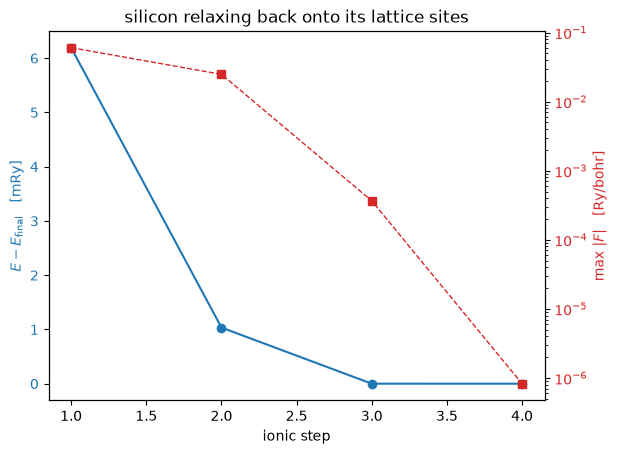

In [2]:
# The input asks for conv_thr = 1e-8; the claim being shown is a 1e-6 bohr
# agreement on the final geometry, which is tighter than that SCF can support.
relax = Calculator.from_file(CASES / "si2-nc-relax.in", pseudo_dir=PSEUDO,
                             conv_thr=1e-10)
relaxed = relax.get_relax()
theirs = read_qe_output(CASES / "reference.out.si2-nc-relax")

relaxed.plot().set_title("silicon relaxing back onto its lattice sites")

alat = float(relax.system.cell.alat)
for step in relaxed.steps:
    separation = (step.positions[1] - step.positions[0]) / alat
    print("step %d   E = %.8f Ry   max|F| = %.6f   at (%.4f, %.4f, %.4f) alat"
          % (step.index, step.total_energy, step.max_force, *separation))

print("\nfinal energy differs from pw.x by %.1e Ry"
      % abs(relaxed.total_energy - theirs.final_energy))
print("final geometry differs from pw.x by %.1e bohr"
      % np.abs(relaxed.positions - theirs.final_positions).max())

The atoms started at $(0.2700, 0.2500, 0.2500)$ in units of the lattice constant
and finished at $(0.2500, 0.2500, 0.2500)$, which is the ideal diamond site.
That is the whole content of the run: the displaced structure was not a
stationary point, and the relaxation found the one that is.

The energy falls by about 6 mRy and the force falls by five orders of magnitude
in four steps, which is what a BFGS on a quadratic minimum looks like. The last
step barely moves the atoms and barely lowers the energy, and it is the one that
takes the force below the threshold: near a minimum the energy is flat and the
gradient is not, which is why relaxation is converged on the force rather than
on the energy.

QE's own CO relaxation runs here too, with the oxygen held still by `if_pos`,
which is how a constrained geometry, a surface adsorbate or a reaction
coordinate is set up.

## What it refuses

An ultrasoft or PAW **metal** has no dynamical matrix here, but its forces are
fine. A **spin spiral** has no force on an atom: its two spinor components live
on different plane-wave spheres, so `dE/dq`, the derivative with respect to the
spiral's own wavevector, is what a spiral has instead (notebook 14). With a
potential-only meta-GGA such as `tb09` the total energy is not the value of any
functional being minimised, so every derivative of it, forces included, is
refused rather than returned wrong.

---
The tests behind this notebook: `tests/regression/test_forces.py` (the five
reference cases, the term-by-term breakdown, the central difference, and the
identity that the differentiated functional reproduces the SCF total on every
dataset), `tests/regression/test_relax.py`, `tests/unit/test_force_machinery.py`.